# Example use - AOI polygon

This notebook shows how to create a mosaic for a single polygon AOI. Polygon AOIs are useful for long, narrow, or irregular areas where a rectangular bounds mosaic would read a lot of pixels that are not needed.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Polygon

from s2mosaic import mosaic

Define a single valid shapely `Polygon`. The default `input_crs` is EPSG:4326, so these coordinates are lon/lat.

In [2]:
# Winding corridor-style AOI near Perth, WA — non-convex, irregular outline
# where a rectangular bounding box would waste a large fraction of pixels.
aoi = Polygon(
    [
        # northern edge, east to west
        (115.920, -31.945),
        (115.905, -31.950),
        (115.888, -31.948),
        (115.872, -31.956),
        (115.855, -31.952),
        (115.840, -31.960),
        (115.828, -31.968),
        (115.822, -31.974),
        # southern edge, west to east
        (115.830, -31.980),
        (115.848, -31.974),
        (115.862, -31.968),
        (115.878, -31.968),
        (115.895, -31.962),
        (115.912, -31.958),
        (115.926, -31.952),
    ]
)

assert aoi.is_valid

Pass the polygon with `aoi=...`. The output raster is still rectangular, using the polygon bounds, but pixels outside the polygon are skipped during aggregation and written as nodata.

In [3]:
array, profile = mosaic(
    aoi=aoi,
    input_crs=4326,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile_value=50,
    cloud_mask="SCL",
    resolution=10,
    tile_observation_target=3,
    show_progress=True,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Phase 1: streaming cloud masks (SCL):   0%|          | 0/11 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/57 [00:00<?, ?read/s]

Shape: (3, 397, 980)
CRS:   EPSG:32750
Pixel: 10.0m


In [5]:
array, profile = mosaic(
    aoi=aoi,
    input_crs=4326,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile_value=50,
    # cloud_mask="SCL",
    resolution=10,
    tile_observation_target=3,
    show_progress=True,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Phase 1: streaming cloud masks (OCM):   0%|          | 0/11 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/48 [00:00<?, ?read/s]

Shape: (3, 397, 980)
CRS:   EPSG:32750
Pixel: 10.0m


Quick display as RGB. Sentinel-2 reflectance bands are 16-bit, so this uses a percentile stretch for plotting only.

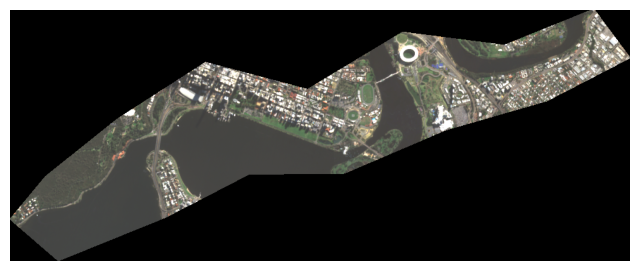

In [4]:
rgb = np.moveaxis(array[:3], 0, -1).astype(float)
hi = np.nanpercentile(rgb[rgb > 0], 98)
rgb = np.clip(rgb / hi, 0, 1)

plt.figure(figsize=(8, 6))
plt.imshow(rgb)
plt.axis("off");

To export directly, pass an `output_path` or `output_dir`. The returned value will be the written path.

In [6]:
out_path = mosaic(
    aoi=aoi,
    input_crs=4326,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="first",
    cloud_mask="SCL",
    resolution=10,
    output_path=Path("output/perth_aoi_first.tif"),
)

out_path

PosixPath('output/perth_aoi_first.tif')